In [11]:
#libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/content/Aviation_Financial_Cleaned.csv")

In [6]:
#finding correlation
ops_fin_cols= ['Delay (Minutes)', 'Turnaround Time (Minutes)', 'Maintenance Downtime (Hours)', 'Profit (USD)', 'Cost_to_Revenue_Ratio']
corr_matrix=df[ops_fin_cols].corr()
corr_matrix["Profit (USD)"].sort_values(ascending=False)

,Profit (USD)
Profit (USD),1.000000
Maintenance Downtime (Hours),0.005797
Delay (Minutes),0.002210
Turnaround Time (Minutes),-0.002211
Cost_to_Revenue_Ratio,-0.607697


In [7]:
#grouping
bins=[0, 30, 60, 90, 150]
labels=["Low (0-30m)","Medium (31-60m)","High (61-90m)","Severe (90m+)"]
df["Delay_Severity"]=pd.cut(df["Delay (Minutes)"],bins=bins,labels=labels,include_lowest=True)

In [9]:
profit_by_del=df.groupby("Delay_Severity")["Profit (USD)"].mean()
print(profit_by_del)

Delay_Severity
Low (0-30m)        5273.011928
Medium (31-60m)    4981.664819
High (61-90m)      5424.653197
Severe (90m+)      5223.876081
Name: Profit (USD), dtype: float64


/tmp/ipykernel_858/3097763237.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  profit_by_del=df.groupby("Delay_Severity")["Profit (USD)"].mean()


/tmp/ipykernel_858/1440103831.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=profit_by_del.index, y=profit_by_del.values, palette='Blues_d')


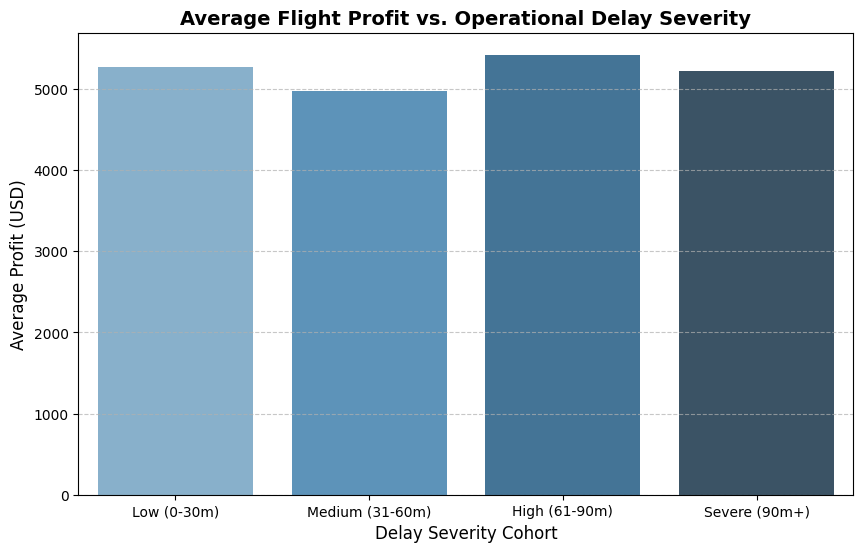

In [12]:
#visualization
plt.figure(figsize=(10, 6))
sns.barplot(x=profit_by_del.index, y=profit_by_del.values, palette='Blues_d')
plt.title('Average Flight Profit vs. Operational Delay Severity', fontsize=14, fontweight='bold')
plt.xlabel('Delay Severity Cohort', fontsize=12)
plt.ylabel('Average Profit (USD)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()